<a href="https://colab.research.google.com/github/manuelagutierrezss16/Integraci-n-de-Datos-y-Prospectiva/blob/main/Manuela_Guti%C3%A9rrez_3_Integracion_(multidimensional)_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RETO 3 — INTEGRACIÓN DE DATOS: CASO US HEALTH INSURANCE**

## Caso de estudio

Una aseguradora de salud con cobertura nacional en los Estados Unidos quiere mejorar la cobertura preventiva de sus afiliados. La entidad necesita identificar **patrones de riesgo epidemiológico** para reorganizar la oferta de servicios médicos e incentivos de salud (en lugar de trasladar pacientes), para lo cual quiere crear **clusters en salud** y analizar la **distribución territorial** de estos grupos por región, con el fin de optimizar la asignación de recursos y programas preventivos.

**Objetivos (Abstracción):**
1. Identificar el número de clusters eficiente para reorganizar la oferta de servicios médicos.
2. Caracterizar las variables clínicas / epidemiológicas (**variables de entrada**) y el costo del siniestro (**variable de salida**) de cada perfil de paciente.
3. Conocer la distribución porcentual de cada cluster por **región** y por **nivel de siniestralidad**.
4. Dejar el repositorio de GitHub organizado con el reto desarrollado.

**Técnica a utilizar:** K-Medoids (algoritmo PAM — *Partitioning Around Medoids*), un método de aprendizaje no supervisado que agrupa n objetos en k clusters seleccionando puntos reales del conjunto de datos (medoides) como centro de cada grupo.

**Fuente de datos:** US Health Insurance Dataset (Kaggle) — `insurance.csv`

## 0. Carga de librerías de trabajo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

XDB = pd.read_csv('/content/insurance.csv')
XDB = XDB.dropna()
XDB.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Exploración inicial de la base de datos

In [2]:
print('Dimensión de la base:', XDB.shape)
XDB.info()

Dimensión de la base: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
XDB.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [4]:
# Variables categóricas de interés
display(XDB['region'].value_counts())
display(XDB['smoker'].value_counts())
display(XDB['sex'].value_counts())

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


,count
smoker,
no,1064
yes,274


,count
sex,
male,676
female,662


/tmp/ipykernel_568/3331734551.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=XDB, x='smoker', y='charges', ax=axes[0,1], palette='Set2')


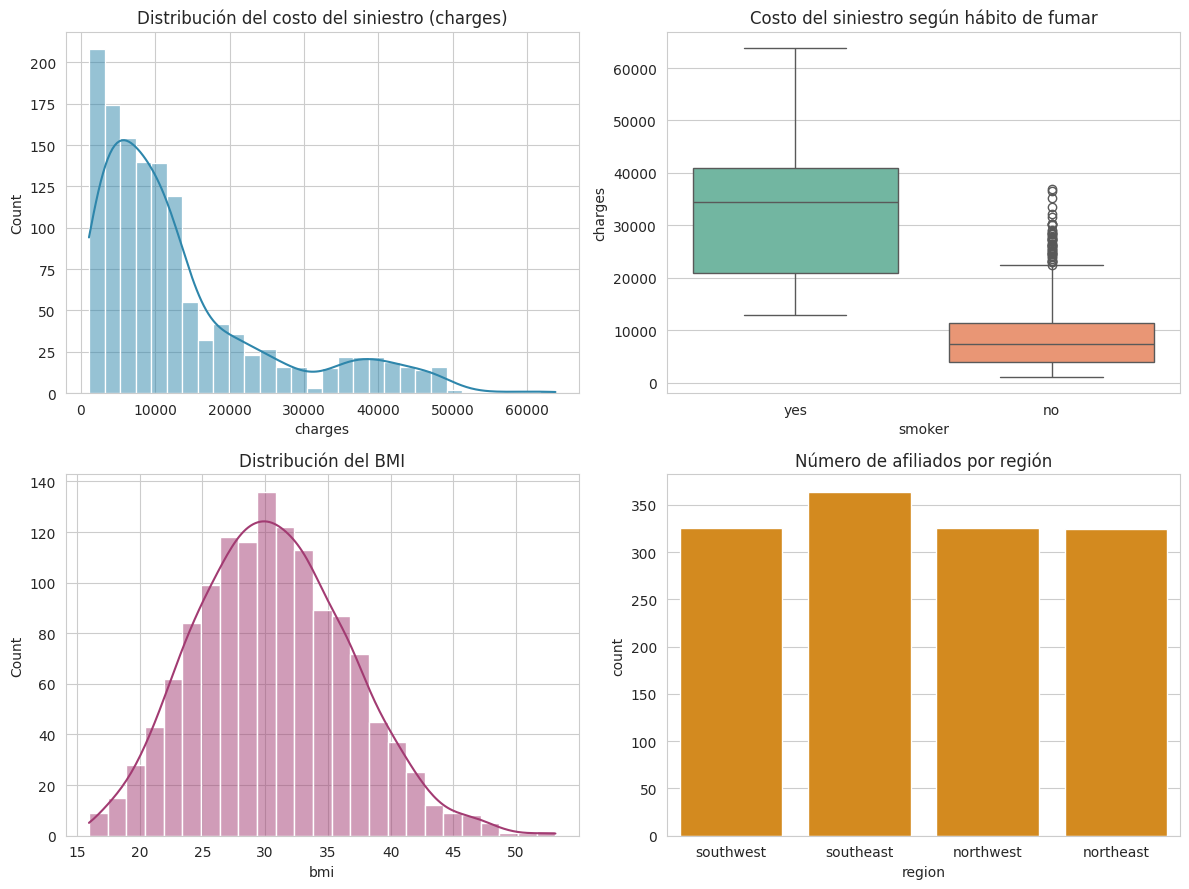

In [5]:
fig, axes = plt.subplots(2,2, figsize=(12,9))

sns.histplot(XDB['charges'], kde=True, ax=axes[0,0], color='#2E86AB')
axes[0,0].set_title('Distribución del costo del siniestro (charges)')

sns.boxplot(data=XDB, x='smoker', y='charges', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Costo del siniestro según hábito de fumar')

sns.histplot(XDB['bmi'], kde=True, ax=axes[1,0], color='#A23B72')
axes[1,0].set_title('Distribución del BMI')

sns.countplot(data=XDB, x='region', ax=axes[1,1], color='#F18F01')
axes[1,1].set_title('Número de afiliados por región')

plt.tight_layout()
plt.show()

**Primeras conclusiones:** el costo del siniestro (`charges`) está sesgado a la derecha y el hábito de fumar separa claramente dos grupos de costo del siniestro (los fumadores presentan siniestros mucho más altos). La base está balanceada por región (aolo aumenta un poco sur este).

## 2. Preparación de las bases de datos de integración


* **XD**: variables de entrada → `age`, `sex`, `bmi`, `children`, `smoker`
* **XDB2**: base completa + variable de salida

In [6]:
# Copia de trabajo y codificación de variables categóricas
XDB2 = XDB.copy()
XDB2['sex_enc'] = XDB2['sex'].map({'male': 0, 'female': 1}) # SE CONVIERTE EN NUMERICA
XDB2['smoker_enc'] = XDB2['smoker'].map({'no': 0, 'yes': 1})

# SE CONSTRUYE LA BASE DE DATOS SOLO CON VARIABLES DE ENTRADA (XD)
# (variables clínicas/epidemiológicas -> se excluyen charges y region)
input_cols = ['age', 'sex_enc', 'bmi', 'children', 'smoker_enc']
XD = XDB2[input_cols]
XD.head()

,age,sex_enc,bmi,children,smoker_enc
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [7]:
# Escalado
scaler = MinMaxScaler()
XDs = scaler.fit_transform(XD)
XDs = pd.DataFrame(XDs, columns=input_cols)
XDs.head()

,age,sex_enc,bmi,children,smoker_enc
0,0.021739,1.0,0.321227,0.0,1.0
1,0.000000,0.0,0.479150,0.2,0.0
2,0.217391,0.0,0.458434,0.6,0.0
3,0.326087,0.0,0.181464,0.0,0.0
4,0.304348,0.0,0.347592,0.0,0.0


## 3. Algoritmo K-Medoids (PAM)


In [8]:
def pam_asignar(X, medoide_idx):
    '''Asigna cada punto al medoide más cercano y calcula el costo total.'''
    medoides = X[medoide_idx]
    d = np.linalg.norm(X[:, None, :] - medoides[None, :, :], axis=2)
    etiquetas = np.argmin(d, axis=1)
    costo = d[np.arange(len(X)), etiquetas].sum()
    return etiquetas, costo


def kmedoids_pam(X, k, seed=7, max_iter=50):
    '''K-Medoids clásico (algoritmo PAM) implementado con numpy.'''
    rng = np.random.RandomState(seed)
    n = len(X)
    medoide_idx = list(rng.choice(n, k, replace=False))
    etiquetas, costo = pam_asignar(X, medoide_idx)

    mejora = True
    it = 0
    while mejora and it < max_iter:
        mejora = False
        it += 1
        for pos in range(k):
            mejor_candidato = None
            for cand in range(n):
                if cand in medoide_idx:
                    continue
                nuevos_medoides = medoide_idx.copy()
                nuevos_medoides[pos] = cand
                _, nuevo_costo = pam_asignar(X, nuevos_medoides)
                if nuevo_costo < costo - 1e-9:
                    costo = nuevo_costo
                    mejor_candidato = cand
            if mejor_candidato is not None:
                medoide_idx[pos] = mejor_candidato
                mejora = True

    etiquetas, costo = pam_asignar(X, medoide_idx)
    return medoide_idx, etiquetas, costo

print('Funciones de K-Medoids (PAM) listas.')

Funciones de K-Medoids (PAM) listas.


## 4. Número de clusters eficiente (método del codo + silueta)

 Se corre PAM para varios valores de k y se compara el **costo total** (suma de distancias, método del codo) con el **coeficiente de silueta** (qué tan bien separados/compactos quedan los grupos).

In [9]:
X = XDs.values
resultados = {}

for k in range(2, 9):
    medoide_idx, etiquetas, costo = kmedoids_pam(X, k, seed=7, max_iter=15)
    sil = silhouette_score(X, etiquetas)
    resultados[k] = (costo, sil)
    print(f'k={k} -> costo={costo:.1f}  silueta={sil:.3f}')

k=2 -> costo=718.9  silueta=0.424
k=3 -> costo=608.6  silueta=0.456
k=4 -> costo=530.2  silueta=0.529
k=5 -> costo=480.0  silueta=0.453
k=6 -> costo=452.9  silueta=0.450
k=7 -> costo=401.6  silueta=0.395
k=8 -> costo=378.0  silueta=0.383


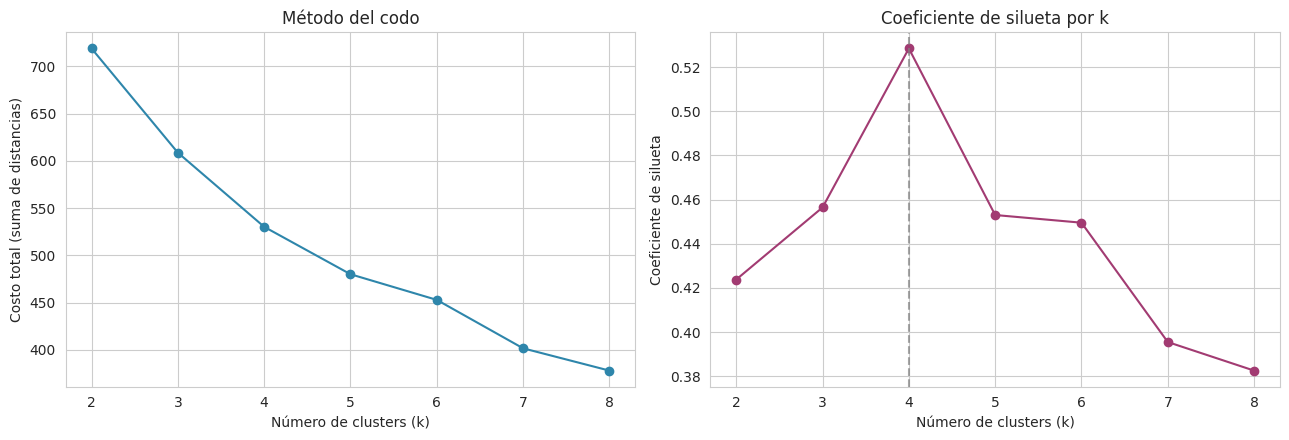

k con mejor silueta: 4 (silueta = 0.529)


In [10]:
ks = list(resultados.keys())
costos = [resultados[k][0] for k in ks]
siluetas = [resultados[k][1] for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

axes[0].plot(ks, costos, marker='o', color='#2E86AB')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Costo total (suma de distancias)')
axes[0].set_title('Método del codo')

axes[1].plot(ks, siluetas, marker='o', color='#A23B72')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Coeficiente de silueta por k')
k_opt = ks[int(np.argmax(siluetas))]
axes[1].axvline(k_opt, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f'k con mejor silueta: {k_opt} (silueta = {max(siluetas):.3f})')

**Selección de k:**  Al no lograr identificar el codo pasamos a ver el coeficiente de la silueta unicamente que alcanza su **máximo en k=4**.

## 5. Clusterización final con K-Medoids (k=4)

In [11]:
k_final = 4
medoide_idx, etiquetas, costo_final = kmedoids_pam(X, k_final, seed=7, max_iter=50)

XDB2['Cluster'] = etiquetas
print('Índices (filas) de los medoides finales:', medoide_idx)
print('Costo total final:', round(costo_final, 2))
XDB2[['age','sex','bmi','children','smoker','region','charges','Cluster']].head()

Índices (filas) de los medoides finales: [669, 922, 1278, 280]
Costo total final: 530.17


,age,sex,bmi,children,smoker,region,charges,Cluster
0,19,female,27.900,0,yes,southwest,16884.92400,3
1,18,male,33.770,1,no,southeast,1725.55230,1
2,28,male,33.000,3,no,southeast,4449.46200,1
3,33,male,22.705,0,no,northwest,21984.47061,1
4,32,male,28.880,0,no,northwest,3866.85520,1


In [12]:
# Perfil (medoide real) de cada cluster -> paciente "representativo" del grupo
perfil_medoides = XDB2.iloc[medoide_idx][['age','sex','bmi','children','smoker','region','charges']].reset_index(drop=True)
perfil_medoides.index.name = 'Cluster'
perfil_medoides

,age,sex,bmi,children,smoker,region,charges
Cluster,,,,,,,
0,40,female,29.810,1,no,southeast,6500.23590
1,38,male,31.000,1,no,southwest,5488.26200
2,39,male,29.925,1,yes,northeast,22462.04375
3,40,female,28.120,1,yes,northeast,22331.56680


## 6. Caracterización clínica y de costo de cada cluster

Ahora sí se incorporan las **variables de salida** (`charges`, costo del siniestro) para caracterizar cada grupo formado a partir de las variables clínicas de entrada.

In [13]:
caracterizacion = XDB2.groupby('Cluster').agg(
    n_pacientes=('age','size'),
    edad_prom=('age','mean'),
    bmi_prom=('bmi','mean'),
    hijos_prom=('children','mean'),
    pct_fumador=('smoker_enc','mean'),
    pct_mujer=('sex_enc','mean'),
    costo_prom=('charges','mean'),
    costo_mediana=('charges','median'),
).round(2)

caracterizacion['pct_fumador'] = (caracterizacion['pct_fumador']*100).round(1)
caracterizacion['pct_mujer'] = (caracterizacion['pct_mujer']*100).round(1)
caracterizacion

,n_pacientes,edad_prom,bmi_prom,hijos_prom,pct_fumador,pct_mujer,costo_prom,costo_mediana
Cluster,,,,,,,,
0,547,39.69,30.54,1.09,0.0,100.0,8762.30,7639.42
1,517,39.06,30.77,1.09,0.0,0.0,8087.20,6985.51
2,159,38.45,31.50,1.19,100.0,0.0,33042.01,36085.22
3,115,38.61,29.61,1.01,100.0,100.0,30679.00,28950.47


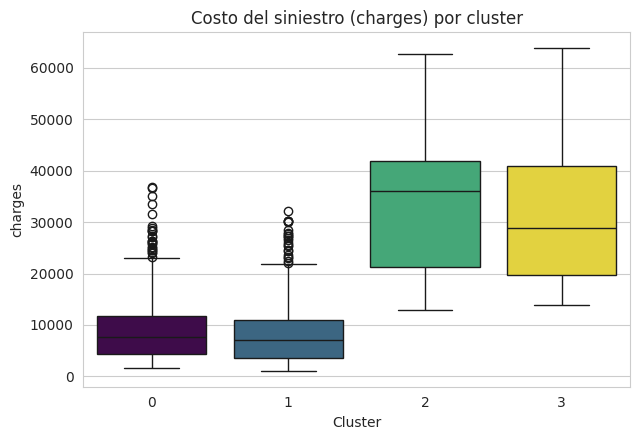

In [20]:
fig, ax = plt.subplots(1,1, figsize=(6.5,4.5))

sns.boxplot(data=XDB2, x='Cluster', y='charges', hue='Cluster', palette='viridis', legend=False, ax=ax)
ax.set_title('Costo del siniestro (charges) por cluster')

plt.tight_layout()
plt.show()

**Análisis:** los cuatro clusters quedan diferenciados principalmente por **hábito de fumar** y **sexo**, dos variables clínicas. Los clusters de **fumadores** concentran los costos de siniestro más altos y más dispersos (mediana muy por encima de los no fumadores), mientras que edad y BMI se comportan de forma similar entre grupos, es decir, **fumar es el factor que más incrementa el riesgo de costo**.

## 7. Distribución territorial de los clusters (por región)

In [15]:
dist_region = pd.crosstab(XDB2['Cluster'], XDB2['region'], normalize='index').round(3)*100
dist_region.columns = [c.replace('_',' ').title() for c in dist_region.columns]
dist_region

,Northeast,Northwest,Southeast,Southwest
Cluster,,,,
0,24.1,24.7,25.4,25.8
1,24.2,25.5,25.9,24.4
2,23.9,18.2,34.6,23.3
3,25.2,25.2,31.3,18.3


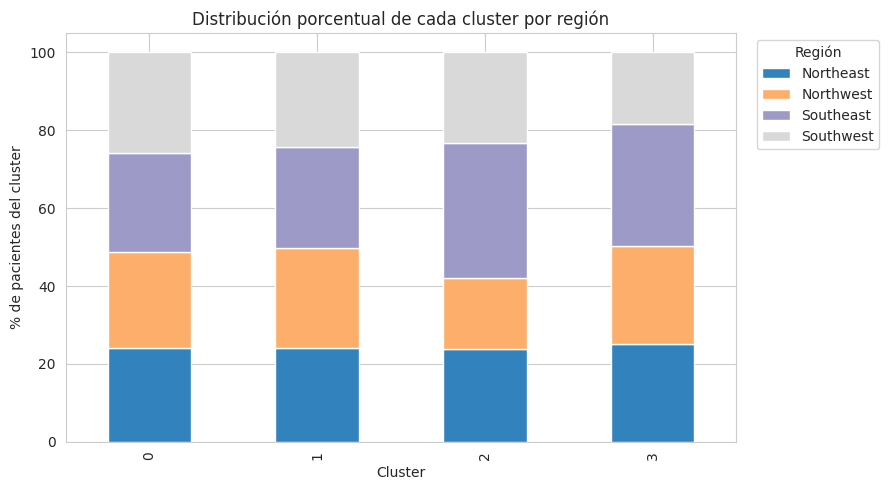

In [16]:
dist_region.plot(kind='bar', stacked=True, colormap='tab20c', figsize=(9,5))
plt.ylabel('% de pacientes del cluster')
plt.title('Distribución porcentual de cada cluster por región')
plt.legend(title='Región', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

**Análisis:** ningún cluster está concentrado por zonas, cada uno se distribuye de forma **casi pareja entre las 4 regiones** (southeast muestra más fumadores).

## 8. Distribución de siniestralidad (costo) por cluster

In [17]:
# Se definen niveles de siniestralidad con base en terciles del costo total
q1, q2 = XDB2['charges'].quantile([0.33, 0.66])

def nivel_siniestro(c):
    if c <= q1:
        return 'Bajo'
    elif c <= q2:
        return 'Medio'
    return 'Alto'

XDB2['Siniestralidad'] = XDB2['charges'].apply(nivel_siniestro)

dist_siniestro = pd.crosstab(XDB2['Cluster'], XDB2['Siniestralidad'], normalize='index')[['Bajo','Medio','Alto']].round(3)*100
dist_siniestro

Siniestralidad,Bajo,Medio,Alto
Cluster,,,
0,40.2,41.1,18.6
1,42.9,41.8,15.3
2,0.0,0.0,100.0
3,0.0,0.0,100.0


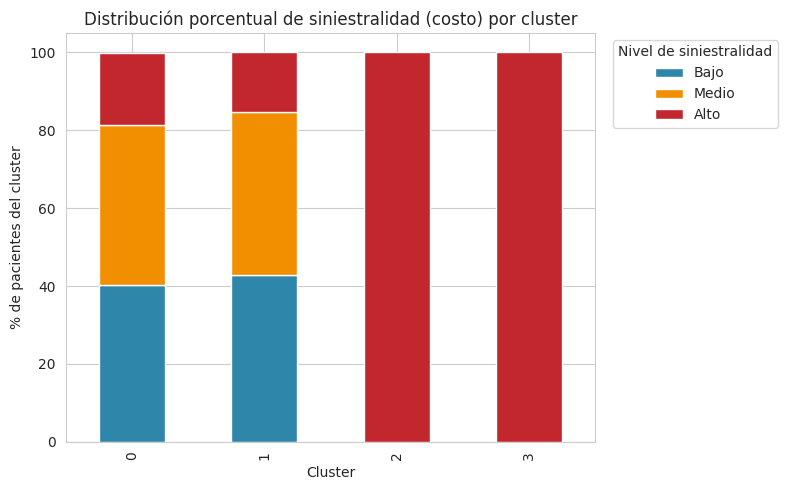

In [18]:
dist_siniestro.plot(kind='bar', stacked=True, color=['#2E86AB','#F18F01','#C1272D'], figsize=(8,5))
plt.ylabel('% de pacientes del cluster')
plt.title('Distribución porcentual de siniestralidad (costo) por cluster')
plt.legend(title='Nivel de siniestralidad', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Resumen ejecutivo y recomendaciones



**Análisis:** los clusters se dividen en 4 basados en gran medida en si fuma y en su sexo, todos estos clusters se muestran en laas 4 regiones identificando que en sur este estan más representados los clusters 2 y 3 (fumadores) por lo que si se quiere hacer una mejora de instalaciones o programas se deben de haccer en todas las sedes con un leve enfacis en las del sur este. los clusters de fumadores concentran el 100% de la siniestros altos, mientras que los clusters de no fumadores se reparten entre siniestralidad baja y media, sin registrar siniestros altos. Esto confirma cuantitativamente que el hábito de fumar es el principal detonante del costo, y que enfocar programas preventivos con estos tendría el mayor impacto posible en la reducción de los siniestros altos, sin necesidad de trasladar pacientes entre sedes.

**Recomendaciones para la aseguradora:**
1. El **hábito de fumar** (no la región, ni la edad) es la variable que más explica el costo del siniestro; los programas de incentivos de salud deben priorizarse en los clusters 2 y 3.
2. Como los clusters se distribuyen de forma pareja por región, **no es necesario trasladar pacientes** entre sedes: los mismos programas preventivos deben implementarse de manera igualitaria en las 4 regiones.